# Advertising Incrementality with the Criteo Uplift Experiment

## Randomized treatment–control analysis

This notebook studies whether **assignment to an advertising campaign** changes website visits and conversions. It is designed as the first part of a portfolio project for causal-inference and research data-science roles.

The central question is:

> What is the incremental effect of making a user eligible to receive campaign ads, compared with withholding those ads?

We begin with the randomized comparison. We do **not** initially treat actual ad exposure as randomized.

## Data source

This analysis uses the public Criteo Uplift dataset from the Criteo Research repository. The data comes from a randomized advertising experiment where users were assigned to become eligible for a campaign or withheld from it, and the dataset includes anonymized pre-treatment features, treatment assignment, ad exposure, site visit, and conversion outcomes.

The raw CSV file is loaded from a hosted dataset source so the notebook can reproduce the analysis without requiring a local copy.

## 1. Variables and causal question

For user $i$:

- $Z_i=\texttt{treatment}$: randomized assignment. `1` means eligible for campaign ads; `0` means ads withheld.
- $D_i=\texttt{exposure}$: whether the user actually saw an ad.
- $V_i=\texttt{visit}$: whether the user visited the advertiser's website.
- $Y_i=\texttt{conversion}$: whether the user completed the advertiser's target action.
- $X_i=(f_0,\ldots,f_{11})$: anonymized pre-treatment user features.

A control user can still visit or convert through search, email, a bookmark, another channel, or prior familiarity. Control outcomes estimate the baseline that would occur without this campaign.

### Treatment is not the same as exposure

| `treatment` | `exposure` | Interpretation |
|---:|---:|---|
| 0 | 0 | Assigned to control; campaign ad withheld |
| 1 | 0 | Eligible for ads but did not actually see one |
| 1 | 1 | Eligible and actually saw an ad |

Treatment assignment is randomized. Exposure generally is not: exposed users may browse more, be easier to reach, or have higher prior purchase intent. Therefore, treatment versus control supports a causal estimate; exposed versus unexposed is only a descriptive comparison unless additional assumptions or methods are introduced.

## 2. Potential outcomes and estimand

Each user has two conceptual outcomes:

- $Y_i(1)$: conversion if assigned to treatment.
- $Y_i(0)$: conversion if assigned to control.

Only one is observed. The average treatment effect of assignment—also called the intention-to-treat effect here—is

$$\tau_{ITT}=E[Y_i(1)-Y_i(0)].$$

Random assignment implies $Z_i \perp (Y_i(1),Y_i(0))$, so the difference in sample means is an unbiased estimator:

$$\widehat{\tau}_{ITT}=\bar Y_{Z=1}-\bar Y_{Z=0}.$$

For one realized experiment, however,

$$\text{observed difference}=\text{treatment-effect estimate}+\text{random variation}.$$

Randomization does not guarantee that every observed difference was caused by treatment. It makes random imbalance average to zero across repeated assignments. Confidence intervals and hypothesis tests quantify the uncertainty.

In [1]:
# If needed, uncomment the next line. The hf:// URL requires a recent pandas
# installation plus fsspec/huggingface_hub support.
# %pip install -q pandas numpy scipy matplotlib seaborn statsmodels fsspec huggingface_hub

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_SEED = 42


## 3. Load the data efficiently

The full dataset is large, so compact dtypes substantially reduce memory use. The analysis below uses all rows; sampling is used only for plots where appropriate.

In [2]:
DATA_URL = "hf://datasets/criteo/criteo-uplift/criteo-research-uplift-v2.1.csv.gz"
FEATURES = [f"f{i}" for i in range(12)]
BINARY_COLUMNS = ["treatment", "exposure", "visit", "conversion"]
USECOLS = FEATURES + BINARY_COLUMNS

DTYPES = {
    **{feature: "float32" for feature in FEATURES},
    **{column: "int8" for column in BINARY_COLUMNS},
}

df = pd.read_csv(DATA_URL, usecols=USECOLS, dtype=DTYPES)
print(f"Rows: {len(df):,}; columns: {df.shape[1]}")
print(f"Approximate DataFrame memory: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
df.head()

Rows: 13,979,592; columns: 16
Approximate DataFrame memory: 693.3 MB


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616364,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616364,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616364,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616364,10.059654,9.002801,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
4,12.616364,10.059654,9.037999,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


## 4. Data-quality and logical checks

Before estimating effects, verify the schema, missingness, binary coding, and basic logical relationships. A failed assertion is useful: it identifies an assumption that must be investigated rather than silently accepted.

In [3]:
assert set(USECOLS).issubset(df.columns), "Expected columns are missing."
assert not df[USECOLS].isna().any().any(), "Missing values found."

for column in BINARY_COLUMNS:
    observed_values = set(df[column].unique())
    assert observed_values.issubset({0, 1}), f"{column} is not binary: {observed_values}"

quality_checks = pd.Series({
    "duplicate rows": int(df.duplicated().sum()),
    "control users marked exposed": int(((df.treatment == 0) & (df.exposure == 1)).sum()),
    "conversions without recorded visit": int(((df.conversion == 1) & (df.visit == 0)).sum()),
}, name="count")
quality_checks.to_frame()

,count
duplicate rows,1655747
control users marked exposed,0
conversions without recorded visit,0


Do not automatically delete duplicate-looking rows: the anonymized columns may make distinct users appear identical. Similarly, a conversion-without-visit record may reflect measurement definitions rather than bad data. Document what the checks reveal.

## 5. Understand assignment, exposure, visits, and conversions

These tables establish the experiment size, assignment ratio, outcome rarity, and treatment-to-exposure compliance pattern.

In [4]:
assignment_summary = (
    df.groupby("treatment")
      .agg(users=("treatment", "size"),
           exposure_rate=("exposure", "mean"),
           visit_rate=("visit", "mean"),
           conversion_rate=("conversion", "mean"))
)
assignment_summary["assignment_share"] = assignment_summary["users"] / len(df)
assignment_summary[["users", "assignment_share", "exposure_rate", "visit_rate", "conversion_rate"]]

,users,assignment_share,exposure_rate,visit_rate,conversion_rate
treatment,,,,,
0,2096937,0.150000,0.000000,0.038201,0.001938
1,11882655,0.850000,0.036037,0.048543,0.003089


In [5]:
# Counts and within-assignment percentages for actual exposure.
exposure_table = pd.crosstab(df["treatment"], df["exposure"], margins=True)
exposure_rates = pd.crosstab(df["treatment"], df["exposure"], normalize="index")
display(exposure_table)
display(exposure_rates.rename(columns={0: "not exposed", 1: "exposed"}))

exposure,0,1,All
treatment,,,
0,2096937,0,2096937
1,11454443,428212,11882655
All,13551380,428212,13979592


exposure,not exposed,exposed
treatment,,
0,1.000000,0.000000
1,0.963963,0.036037


## 6. Reusable randomized-effect function

For a binary outcome, the unpooled standard error of the difference in proportions is

$$SE(\widehat\tau)=\sqrt{\frac{\widehat p_T(1-\widehat p_T)}{n_T}+\frac{\widehat p_C(1-\widehat p_C)}{n_C}}.$$

A 95% Wald confidence interval is $\widehat\tau \pm 1.96SE(\widehat\tau)$. The two-sided test asks whether the observed difference is inconsistent with $H_0:p_T-p_C=0$. With millions of observations, also emphasize effect size and business significance—not only the p-value.

In [6]:
def randomized_binary_effect(data, outcome, assignment="treatment", alpha=0.05):
    """Estimate the treatment-control difference for a randomized binary outcome."""
    treated = data.loc[data[assignment] == 1, outcome]
    control = data.loc[data[assignment] == 0, outcome]

    n_t, n_c = treated.size, control.size
    p_t, p_c = treated.mean(), control.mean()
    absolute_lift = p_t - p_c
    relative_lift = absolute_lift / p_c if p_c != 0 else np.nan
    se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)
    critical_value = norm.ppf(1 - alpha / 2)
    ci_low = absolute_lift - critical_value * se
    ci_high = absolute_lift + critical_value * se
    z_stat = absolute_lift / se
    p_value = 2 * norm.sf(abs(z_stat))

    return pd.Series({
        "control_users": n_c,
        "treatment_users": n_t,
        "control_rate": p_c,
        "treatment_rate": p_t,
        "absolute_lift": absolute_lift,
        "relative_lift": relative_lift,
        "standard_error": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "z_statistic": z_stat,
        "p_value": p_value,
        "incremental_events_in_treatment": n_t * absolute_lift,
    })

## 7. Main result: effect on conversion

Absolute lift is measured as a probability difference. Multiply it by 100 to report **percentage points**. Relative lift divides by the control baseline. Estimated incremental conversions equal $n_T\widehat\tau$; this is an estimate, not a list of identifiable individuals whose conversion was caused by the campaign.

In [7]:
conversion_result = randomized_binary_effect(df, "conversion")
conversion_result.to_frame("estimate")

,estimate
control_users,"2,096,937.000000"
treatment_users,"11,882,655.000000"
control_rate,0.001938
treatment_rate,0.003089
absolute_lift,0.001152
relative_lift,0.594488
standard_error,0.000034
ci_low,0.001085
ci_high,0.001219
z_statistic,33.512267


In [8]:
print(f"Control conversion rate:   {conversion_result.control_rate:.6%}")
print(f"Treatment conversion rate: {conversion_result.treatment_rate:.6%}")
print(f"Absolute lift:              {conversion_result.absolute_lift:.6%} "
      f"({100 * conversion_result.absolute_lift:.4f} percentage points)")
print(f"Relative lift:              {conversion_result.relative_lift:.2%}")
print(f"95% CI for absolute lift:  [{conversion_result.ci_low:.6%}, "
      f"{conversion_result.ci_high:.6%}]")
print(f"z-statistic:                {conversion_result.z_statistic:.3f}")
print(f"Two-sided p-value:          {conversion_result.p_value:.6g}")
print(f"Estimated incremental conversions among treated users: "
      f"{conversion_result.incremental_events_in_treatment:,.1f}")

Control conversion rate:   0.193759%
Treatment conversion rate: 0.308946%
Absolute lift:              0.115187% (0.1152 percentage points)
Relative lift:              59.45%
95% CI for absolute lift:  [0.108451%, 0.121924%]
z-statistic:                33.512
Two-sided p-value:          3.19411e-246
Estimated incremental conversions among treated users: 13,687.3


### Independent check with a standard two-proportion z-test

This test uses a pooled variance under the null, so its test statistic can differ slightly from `effect / unpooled_SE`. Both are large-sample procedures.

In [9]:
successes = np.array([
    df.loc[df.treatment == 1, "conversion"].sum(),
    df.loc[df.treatment == 0, "conversion"].sum(),
])
observations = np.array([
    (df.treatment == 1).sum(),
    (df.treatment == 0).sum(),
])
pooled_z, pooled_p = proportions_ztest(successes, observations, alternative="two-sided")
print(f"Pooled two-proportion z-statistic: {pooled_z:.3f}")
print(f"Pooled two-sided p-value: {pooled_p:.6g}")

Pooled two-proportion z-statistic: 28.517
Pooled two-sided p-value: 7.30826e-179


## 8. Secondary outcome: effect on website visits

Visits are an intermediate outcome. A campaign might increase traffic substantially while producing a smaller conversion effect. Analyze both, but state that testing multiple outcomes creates multiple-testing concerns if both are treated as confirmatory endpoints.

In [10]:
results = pd.DataFrame({
    outcome: randomized_binary_effect(df, outcome)
    for outcome in ["visit", "conversion"]
}).T

results[["control_rate", "treatment_rate", "absolute_lift",
         "relative_lift", "ci_low", "ci_high", "p_value",
         "incremental_events_in_treatment"]]

,control_rate,treatment_rate,absolute_lift,relative_lift,ci_low,ci_high,p_value,incremental_events_in_treatment
visit,0.038201,0.048543,0.010342,0.270737,0.010056,0.010629,0.000000,"122,895.208255"
conversion,0.001938,0.003089,0.001152,0.594488,0.001085,0.001219,0.000000,"13,687.310082"


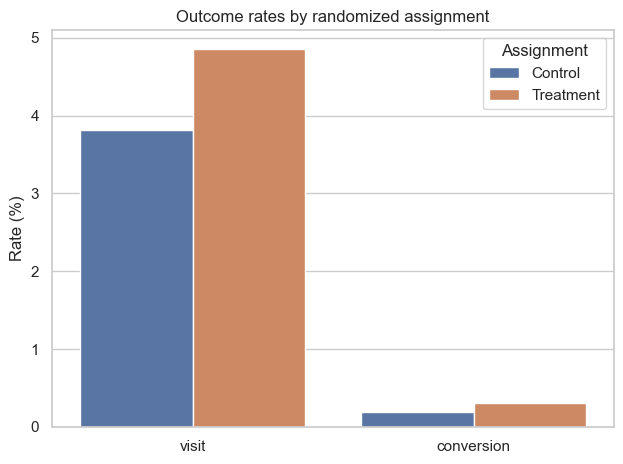

In [11]:
plot_data = (
    df.groupby("treatment")[["visit", "conversion"]]
      .mean()
      .rename(index={0: "Control", 1: "Treatment"})
      .mul(100)
      .reset_index()
      .melt(id_vars="treatment", var_name="Outcome", value_name="Rate (%)")
)

ax = sns.barplot(data=plot_data, x="Outcome", y="Rate (%)", hue="treatment")
ax.set_title("Outcome rates by randomized assignment")
ax.set_xlabel("")
ax.legend(title="Assignment")
plt.tight_layout()
plt.show()

## 9. Randomization balance checks

Randomization makes covariate balance true **in expectation**, not exact in a realized sample. We inspect standardized mean differences (SMDs):

$$SMD_j=\frac{\bar X_{T,j}-\bar X_{C,j}}{\sqrt{(s^2_{T,j}+s^2_{C,j})/2}}.$$

Unlike p-values, SMDs are less mechanically driven by this enormous sample size. A common diagnostic convention is $|SMD|<0.1$, but it is not a proof of correct randomization and should not be treated as a universal law.

In [12]:
def standardized_mean_differences(data, features, assignment="treatment"):
    treated = data.loc[data[assignment] == 1, features]
    control = data.loc[data[assignment] == 0, features]
    pooled_sd = np.sqrt((treated.var() + control.var()) / 2)
    smd = (treated.mean() - control.mean()) / pooled_sd.replace(0, np.nan)
    return pd.DataFrame({
        "control_mean": control.mean(),
        "treatment_mean": treated.mean(),
        "smd": smd,
        "abs_smd": smd.abs(),
    }).sort_values("abs_smd", ascending=False)

balance = standardized_mean_differences(df, FEATURES)
balance

,control_mean,treatment_mean,smd,abs_smd
f3,4.232821,4.169412,-0.048660,0.048660
f6,-3.999880,-4.182793,-0.040626,0.040626
f5,4.039338,4.026602,-0.030694,0.030694
f9,15.886255,16.052589,0.024411,0.024411
f7,5.080285,5.105556,0.020498,0.020498
f8,3.934652,3.933392,-0.015916,0.015916
f0,19.651705,19.614754,-0.006813,0.006813
f1,10.067936,10.070336,0.006191,0.006191
f11,-0.170868,-0.170985,-0.004586,0.004586
f2,8.448174,8.446302,-0.004586,0.004586


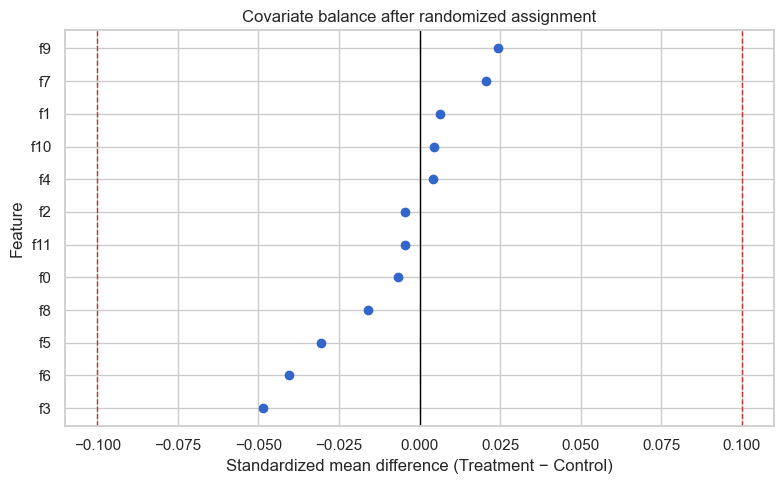

In [13]:
balance_plot = balance.sort_values("smd")
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(balance_plot["smd"], balance_plot.index, color="#3366cc")
ax.axvline(0, color="black", linewidth=1)
ax.axvline(-0.1, color="#cc3333", linestyle="--", linewidth=1)
ax.axvline(0.1, color="#cc3333", linestyle="--", linewidth=1)
ax.set_title("Covariate balance after randomized assignment")
ax.set_xlabel("Standardized mean difference (Treatment − Control)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Attribution is not incrementality

The randomized estimand is

$$E[Y\mid Z=1]-E[Y\mid Z=0].$$

The naive exposure difference is

$$E[Y\mid D=1]-E[Y\mid D=0].$$

The second comparison is useful descriptively, but exposure was not randomized. It combines any ad effect with selection into exposure. Comparing the two illustrates why crediting all conversions following an ad is not the same as measuring incremental conversions.

In [14]:
randomized_effect = (
    df.loc[df.treatment == 1, "conversion"].mean()
    - df.loc[df.treatment == 0, "conversion"].mean()
)
naive_exposure_difference = (
    df.loc[df.exposure == 1, "conversion"].mean()
    - df.loc[df.exposure == 0, "conversion"].mean()
)

comparison = pd.DataFrame({
    "comparison": ["Randomized treatment − control", "Naive exposed − unexposed"],
    "conversion_rate_difference": [randomized_effect, naive_exposure_difference],
    "causal_without_extra_assumptions": [True, False],
})
comparison

,comparison,conversion_rate_difference,causal_without_extra_assumptions
0,Randomized treatment − control,0.001152,True
1,Naive exposed − unexposed,0.052475,False


## 11. Conclusion

In the Criteo randomized advertising experiment, assignment to the advertising-eligible group changed conversion probability by **0.1152 percentage points** relative to a control baseline of **0.193759%**. This corresponds to a **59.45% relative change**. The 95% confidence interval for the absolute effect was **[0.108451%, 0.121924%] percentage points**, and the two-sided p-value was **3.19411e-246**. Applied to the treatment group, the estimate corresponds to approximately **13,687.3** incremental conversions. Because this is a randomized treatment-assignment comparison, the estimator has a causal interpretation under the experimental assumptions; nevertheless, the realized estimate remains subject to sampling uncertainty.

For the secondary visit outcome, assignment to the advertising-eligible group increased the visit rate from **3.8201%** in control to **4.8543%** in treatment. This is an absolute lift of **1.0342 percentage points** (95% CI: **1.0056 to 1.0629 percentage points**) and a **27.07% relative lift** over the control visit rate. The confidence interval excludes zero and the two-sided p-value is effectively zero at the displayed numerical precision, providing very strong evidence that the observed visit lift is not explained by random assignment variation alone. Applied to the 11,882,655 users assigned to treatment, the estimate corresponds to approximately **122,895 incremental visits**. Thus, the campaign had a precisely estimated, positive effect on website traffic; this conclusion concerns assignment to ad eligibility (the ITT effect), not the effect of actual ad exposure.

## 12. Assumptions and limitations

The randomized interpretation relies on:

1. **Random assignment:** campaign eligibility was genuinely randomized.
2. **No interference:** one user's assignment does not materially alter another user's outcome.
3. **Consistency:** the recorded treatment corresponds to the campaign strategy whose effect we want to describe.
4. **Valid measurement:** assignment and outcomes are recorded consistently across groups.
5. **No differential attrition:** outcome observability does not differ in a treatment-induced way.

The ITT effect answers the impact of the **assignment strategy**, not the effect of forcing a particular user to see an ad. Generalization beyond this campaign, population, platform, and time period also requires judgment. The anonymized features limit substantive explanations for heterogeneity.

## 13. Regression-adjusted intention-to-treat effect

The unadjusted difference in means is already an unbiased estimator of the ITT effect because treatment assignment was randomized. Regression adjustment does **not** repair confounding here. Instead, it uses pre-treatment features to explain some outcome variation and can improve precision. It also checks whether the estimate is stable after accounting for the small chance imbalances seen in the balance table.

We use the fully interacted, covariate-centered linear probability model

$$Y_i = \alpha + \tau Z_i + \beta^\top (X_i-\bar X) + \gamma^\top Z_i(X_i-\bar X) + \varepsilon_i.$$

Here, $Z_i$ is randomized assignment and $X_i$ contains `f0`–`f11`. Centering makes $\tau$ the treatment effect at the sample's average feature values. The treatment-by-feature interactions allow the outcome relationship to differ between treatment and control rather than forcing common slopes. With random assignment and heteroskedasticity-robust standard errors, this is a standard regression-adjusted estimator of the average ITT effect.

We use a linear probability model because its treatment coefficient is directly measured as a change in conversion probability. Logistic-regression coefficients are changes in log-odds and would require a separate standardization step to recover an average probability effect.

> **Important:** adjustment variables must be measured before treatment. Do not add `exposure` or `visit` when conversion is the outcome: both can be changed by assignment, so controlling for them would block part of the treatment effect and change the estimand.

In [15]:
def regression_adjusted_itt(data, outcome, features, assignment="treatment",
                            alpha=0.05, chunk_size=500_000):
    """Lin-style fully interacted OLS adjustment with an HC1 robust SE.

    Cross-products are accumulated in chunks so the 14-million-row dataset
    does not require one enormous float64 design matrix in memory.
    """
    n = len(data)
    feature_means = data[features].mean().to_numpy(dtype=np.float64)
    feature_scales = data[features].std(ddof=0).to_numpy(dtype=np.float64)
    feature_scales = np.where(feature_scales == 0, 1.0, feature_scales)
    k = 2 + 2 * len(features)  # intercept, treatment, X, treatment × X

    def design_matrix(block):
        z = block[assignment].to_numpy(dtype=np.float64)
        x_centered = (
            block[features].to_numpy(dtype=np.float64) - feature_means
        ) / feature_scales
        return np.column_stack([
            np.ones(len(block)), z, x_centered, z[:, None] * x_centered
        ])

    # First pass: OLS coefficients from sufficient statistics.
    xtx = np.zeros((k, k), dtype=np.float64)
    xty = np.zeros(k, dtype=np.float64)
    for start in range(0, n, chunk_size):
        block = data.iloc[start:start + chunk_size]
        design = design_matrix(block)
        y = block[outcome].to_numpy(dtype=np.float64)
        xtx += design.T @ design
        xty += design.T @ y

    bread = np.linalg.pinv(xtx)
    coefficients = bread @ xty

    # Second pass: HC1 sandwich covariance, robust to binary-outcome variance.
    meat = np.zeros((k, k), dtype=np.float64)
    for start in range(0, n, chunk_size):
        block = data.iloc[start:start + chunk_size]
        design = design_matrix(block)
        y = block[outcome].to_numpy(dtype=np.float64)
        residual = y - design @ coefficients
        weighted_design = design * residual[:, None]
        meat += weighted_design.T @ weighted_design

    covariance = (n / (n - k)) * bread @ meat @ bread
    estimate = coefficients[1]
    standard_error = np.sqrt(covariance[1, 1])
    critical_value = norm.ppf(1 - alpha / 2)
    z_statistic = estimate / standard_error

    return pd.Series({
        "adjusted_itt": estimate,
        "standard_error": standard_error,
        "ci_low": estimate - critical_value * standard_error,
        "ci_high": estimate + critical_value * standard_error,
        "z_statistic": z_statistic,
        "p_value": 2 * norm.sf(abs(z_statistic)),
        "sample_size": n,
        "regressors": k,
    })

In [16]:
adjusted_conversion = regression_adjusted_itt(
    df, outcome="conversion", features=FEATURES
)

itt_comparison = pd.DataFrame({
    "Unadjusted difference in means": {
        "estimate": conversion_result.absolute_lift,
        "standard_error": conversion_result.standard_error,
        "ci_low": conversion_result.ci_low,
        "ci_high": conversion_result.ci_high,
        "p_value": conversion_result.p_value,
    },
    "Regression-adjusted ITT": {
        "estimate": adjusted_conversion.adjusted_itt,
        "standard_error": adjusted_conversion.standard_error,
        "ci_low": adjusted_conversion.ci_low,
        "ci_high": adjusted_conversion.ci_high,
        "p_value": adjusted_conversion.p_value,
    },
}).T

itt_comparison["estimate_percentage_points"] = 100 * itt_comparison["estimate"]
itt_comparison["ci_low_percentage_points"] = 100 * itt_comparison["ci_low"]
itt_comparison["ci_high_percentage_points"] = 100 * itt_comparison["ci_high"]
itt_comparison["ci_width_percentage_points"] = (
    itt_comparison["ci_high_percentage_points"]
    - itt_comparison["ci_low_percentage_points"]
)

itt_comparison[[
    "estimate_percentage_points", "standard_error",
    "ci_low_percentage_points", "ci_high_percentage_points",
    "ci_width_percentage_points", "p_value"
]]

,estimate_percentage_points,standard_error,ci_low_percentage_points,ci_high_percentage_points,ci_width_percentage_points,p_value
Unadjusted difference in means,0.115187,0.000034,0.108451,0.121924,0.013473,0.000000
Regression-adjusted ITT,0.100166,0.000034,0.093506,0.106825,0.013318,0.000000


In [17]:
estimate_change_pp = 100 * (
    adjusted_conversion.adjusted_itt - conversion_result.absolute_lift
)
variance_reduction = 1 - (
    adjusted_conversion.standard_error / conversion_result.standard_error
) ** 2

print(f"Adjusted conversion ITT: {100 * adjusted_conversion.adjusted_itt:.6f} percentage points")
print(f"95% CI: [{100 * adjusted_conversion.ci_low:.6f}, "
      f"{100 * adjusted_conversion.ci_high:.6f}] percentage points")
print(f"Change from unadjusted estimate: {estimate_change_pp:+.6f} percentage points")
print(f"Estimated variance reduction from adjustment: {variance_reduction:.2%}")

Adjusted conversion ITT: 0.100166 percentage points
95% CI: [0.093506, 0.106825] percentage points
Change from unadjusted estimate: -0.015022 percentage points
Estimated variance reduction from adjustment: 2.29%


### How to interpret the comparison

Focus on two questions:

1. **Did the point estimate move materially?** A small change is reassuring and expected under successful randomization. A large change would prompt checks of feature definitions, missingness, treatment coding, and model specification; it would not automatically invalidate the randomized estimate.
2. **Did the confidence interval narrow?** A smaller standard error means the pre-treatment features explained enough conversion variation to improve precision. If it barely changes, the adjustment is still a valid robustness check—the anonymized features simply added little predictive information for this rare outcome.

The adjusted estimate answers the same business question as before: the incremental change in conversion probability caused by making a user eligible for the campaign. It is **not** the effect of actual ad exposure and it does not yet tell us which users should be targeted.

## 15. Heterogeneous treatment effects and uplift modeling

The ITT answers whether campaign assignment works **on average**. We now ask whether that effect varies with the pre-treatment features:

$$
\tau(x)
=
E[Y(1)-Y(0)\mid X=x]
=
P(Y=1\mid Z=1,X=x)-P(Y=1\mid Z=0,X=x).
$$

Here, $Y$ is conversion, $Z$ is randomized assignment, and $X=(f0,\ldots,f11)$. The quantity $\tau(x)$ is the **conditional average treatment effect** (CATE), also called uplift.

We use an honest workflow:

1. Randomly separate users into training and test sets **before modeling**.
2. Fit all response models using training users only.
3. Freeze the models.
4. Rank test users by predicted uplift.
5. Use only the randomized outcomes in the test set to estimate realized lift within the ranked groups.

The model's individual predictions cannot be directly verified because we never observe both potential outcomes for one person. What can be verified is whether groups assigned high predicted uplift have larger treatment-control differences than groups assigned low predicted uplift.


In [18]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Make the split once, before fitting either response model. The test set is
# not used for early stopping, hyperparameter selection, or feature selection.
UPLIFT_TRAIN_FRACTION = 0.80
UPLIFT_TRAIN_MAX_PER_ARM = 1_500_000

rng = np.random.default_rng(RANDOM_SEED)
uplift_train_mask = rng.random(len(df)) < UPLIFT_TRAIN_FRACTION

test_columns = FEATURES + ["treatment", "conversion"]
uplift_test = df.loc[~uplift_train_mask, test_columns].copy()

def sample_training_arm(data, split_mask, treatment_value, max_rows, seed):
    arm = data.loc[
        split_mask & data["treatment"].eq(treatment_value),
        FEATURES + ["conversion"],
    ]
    if len(arm) > max_rows:
        arm = arm.sample(n=max_rows, random_state=seed)
    return arm

train_control = sample_training_arm(
    df, uplift_train_mask, treatment_value=0,
    max_rows=UPLIFT_TRAIN_MAX_PER_ARM, seed=RANDOM_SEED,
)
train_treated = sample_training_arm(
    df, uplift_train_mask, treatment_value=1,
    max_rows=UPLIFT_TRAIN_MAX_PER_ARM, seed=RANDOM_SEED + 1,
)

split_summary = pd.DataFrame({
    "users": [len(train_control), len(train_treated), len(uplift_test)],
    "conversion_rate": [
        train_control["conversion"].mean(),
        train_treated["conversion"].mean(),
        uplift_test["conversion"].mean(),
    ],
}, index=["Training: control", "Training: treated", "Held-out test"])

print(f"Held-out share: {len(uplift_test) / len(df):.2%}")
split_summary


Held-out share: 20.01%


,users,conversion_rate
Training: control,1500000,0.001931
Training: treated,1500000,0.003050
Held-out test,2796971,0.002957


## 16. T-learner: two response models

A T-learner fits separate models for the two randomized arms:

$$
\widehat\mu_1(x)=\widehat P(Y=1\mid Z=1,X=x),
\qquad
\widehat\mu_0(x)=\widehat P(Y=1\mid Z=0,X=x).
$$

It then subtracts their predictions:

$$
\widehat\tau(x)=\widehat\mu_1(x)-\widehat\mu_0(x).
$$

Gradient-boosted trees allow nonlinear relationships and interactions among `f0`–`f11`. Uniformly limiting the number of training rows in each arm controls runtime without changing that arm's conversion prevalence. Early stopping uses a validation subset drawn only from the training arm.

This model estimates the effect of **assignment**, not the effect of actual exposure. Do not include `exposure` or `visit`: both occur after assignment and controlling for them can destroy the causal interpretation.


In [19]:
def make_response_model(seed):
    return HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=120,
        max_leaf_nodes=15,
        min_samples_leaf=200,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10,
        random_state=seed,
    )

control_model = make_response_model(RANDOM_SEED)
treated_model = make_response_model(RANDOM_SEED + 1)

control_model.fit(train_control[FEATURES], train_control["conversion"])
treated_model.fit(train_treated[FEATURES], train_treated["conversion"])

print(f"Control model boosting iterations: {control_model.n_iter_}")
print(f"Treated model boosting iterations: {treated_model.n_iter_}")


c:\Users\karth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\karth\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\karth\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\karth\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Control model boosting iterations: 117
Treated model boosting iterations: 82


In [20]:
# Predictions are made only after both models are frozen.
mu0_hat = control_model.predict_proba(uplift_test[FEATURES])[:, 1]
mu1_hat = treated_model.predict_proba(uplift_test[FEATURES])[:, 1]
uplift_test["predicted_control_probability"] = mu0_hat.astype("float32")
uplift_test["predicted_treated_probability"] = mu1_hat.astype("float32")
uplift_test["predicted_uplift"] = (mu1_hat - mu0_hat).astype("float32")

predicted_uplift_summary = uplift_test["predicted_uplift"].describe(
    percentiles=[0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
)
predicted_uplift_summary.to_frame("predicted_uplift")


,predicted_uplift
count,"2,796,971.000000"
mean,0.000989
std,0.007955
min,-0.319364
1%,-0.001148
10%,0.000013
25%,0.000032
50%,0.000038
75%,0.000201
90%,0.001125


## 17. Honest evaluation by uplift decile

Prediction accuracy or ROC-AUC is not enough: a model may accurately identify likely converters while failing to identify users whose behavior is **changed by treatment**.

We rank held-out users by $\widehat\tau(X_i)$ and divide them into ten equally sized groups. Within each test decile $g$, randomization identifies

$$
\widehat\tau_g
=
\overline Y_{g,Z=1}-\overline Y_{g,Z=0}.
$$

Its unpooled standard error is

$$
SE(\widehat\tau_g)
=
\sqrt{
\frac{\widehat p_{g,1}(1-\widehat p_{g,1})}{n_{g,1}}
+
\frac{\widehat p_{g,0}(1-\widehat p_{g,0})}{n_{g,0}}
}.
$$

Decile 1 contains the users predicted to have the greatest uplift. A useful ranking should show larger observed randomized lift near the top than near the bottom. Exact monotonicity is not required because each decile estimate contains sampling noise.


In [21]:
def honest_uplift_table(data, outcome="conversion", assignment="treatment", groups=10):
    evaluated = data[[outcome, assignment, "predicted_uplift"]].copy()
    # Rank first so equal model predictions are assigned deterministically.
    descending_rank = evaluated["predicted_uplift"].rank(
        method="first", ascending=False
    )
    evaluated["uplift_decile"] = (
        pd.qcut(descending_rank, q=groups, labels=False) + 1
    ).astype("int8")

    rows = []
    for decile, group in evaluated.groupby("uplift_decile", sort=True):
        treated = group.loc[group[assignment] == 1, outcome]
        control = group.loc[group[assignment] == 0, outcome]
        p1, p0 = treated.mean(), control.mean()
        effect = p1 - p0
        se = np.sqrt(
            p1 * (1 - p1) / len(treated)
            + p0 * (1 - p0) / len(control)
        )
        predicted = group["predicted_uplift"].mean()
        rows.append({
            "uplift_decile": decile,
            "users": len(group),
            "treated_users": len(treated),
            "control_users": len(control),
            "mean_predicted_uplift": predicted,
            "observed_test_uplift": effect,
            "standard_error": se,
            "ci_low": effect - 1.96 * se,
            "ci_high": effect + 1.96 * se,
        })
    return pd.DataFrame(rows).set_index("uplift_decile")

uplift_by_decile = honest_uplift_table(uplift_test)
uplift_by_decile.assign(
    mean_predicted_uplift_pp=100 * uplift_by_decile["mean_predicted_uplift"],
    observed_test_uplift_pp=100 * uplift_by_decile["observed_test_uplift"],
    ci_low_pp=100 * uplift_by_decile["ci_low"],
    ci_high_pp=100 * uplift_by_decile["ci_high"],
)[[
    "users", "treated_users", "control_users",
    "mean_predicted_uplift_pp", "observed_test_uplift_pp",
    "ci_low_pp", "ci_high_pp",
]]


,users,treated_users,control_users,mean_predicted_uplift_pp,observed_test_uplift_pp,ci_low_pp,ci_high_pp
uplift_decile,,,,,,,
1,279698,241524,38174,0.976768,0.772745,0.636616,0.908874
2,279697,237982,41715,0.064902,0.072343,0.035459,0.109226
3,279697,237026,42671,0.021106,-0.001958,-0.029220,0.025303
4,279697,247156,32541,0.007567,0.001956,-0.015084,0.018996
5,279697,239645,40052,0.004319,0.016281,0.008930,0.023632
6,279697,224969,54728,0.003561,0.001630,-0.005484,0.008745
7,279697,242122,37575,0.003313,0.001699,-0.006398,0.009795
8,279697,232774,46923,0.003200,0.006444,0.003183,0.009705
9,279697,236367,43330,0.002353,0.010653,-0.000031,0.021337


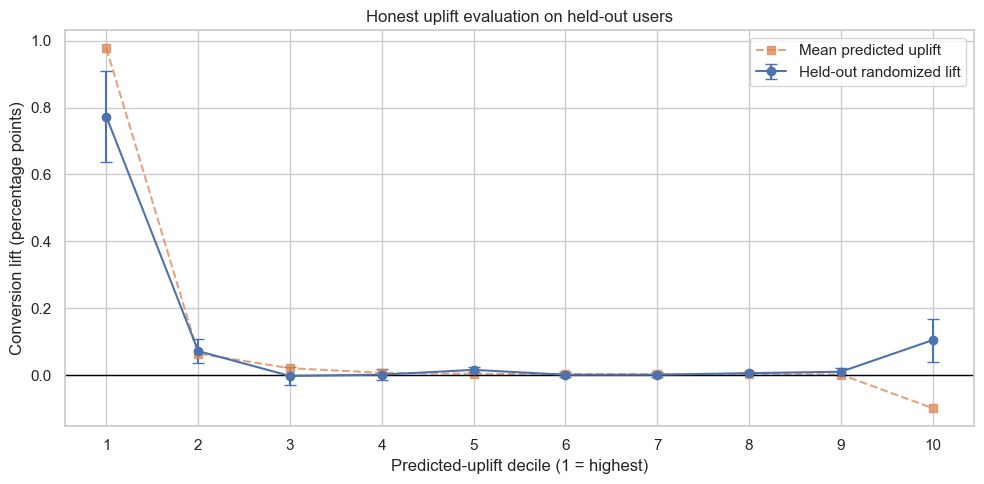

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
x = uplift_by_decile.index.to_numpy()
y = 100 * uplift_by_decile["observed_test_uplift"].to_numpy()
yerr = 100 * np.vstack([
    uplift_by_decile["observed_test_uplift"] - uplift_by_decile["ci_low"],
    uplift_by_decile["ci_high"] - uplift_by_decile["observed_test_uplift"],
])

ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=4, label="Held-out randomized lift")
ax.plot(
    x, 100 * uplift_by_decile["mean_predicted_uplift"],
    "s--", alpha=0.75, label="Mean predicted uplift",
)
ax.axhline(0, color="black", linewidth=1)
ax.set(
    xlabel="Predicted-uplift decile (1 = highest)",
    ylabel="Conversion lift (percentage points)",
    title="Honest uplift evaluation on held-out users",
    xticks=x,
)
ax.legend()
plt.tight_layout()
plt.show()


### Calibration versus ranking

The two lines answer different questions:

- **Ranking:** Does observed lift tend to fall as we move from high- to low-ranked deciles?
- **Calibration:** Are the numerical predictions close to the observed test-set lift?

A model can rank users well while overstating the size of uplift. Ranking is sufficient for deciding whom to prioritize under a fixed campaign budget, but calibrated effects are needed for profit calculations.


## 18. Targeting-policy and Qini evaluation

Suppose the campaign can target only a fraction $q$ of users. For the top-$q$ subgroup selected by the frozen model, estimate

$$
\widehat V(q)
=
N_q\left(\overline Y_{q,Z=1}-\overline Y_{q,Z=0}\right),
$$

the number of incremental conversions expected if that subgroup of size $N_q$ is assigned to the campaign rather than withheld. This is a test-set policy estimate; it is not the sum of unobservable individual outcomes.

The random-targeting benchmark is $qN\widehat\tau_{\text{test}}$. The Qini curve provides a closely related cumulative ranking diagnostic while adjusting for unequal treatment and control counts.


In [27]:
def binary_effect_from_arrays(y, z):
    treated = y[z == 1]
    control = y[z == 0]
    p1, p0 = treated.mean(), control.mean()
    effect = p1 - p0
    se = np.sqrt(
        p1 * (1 - p1) / len(treated)
        + p0 * (1 - p0) / len(control)
    )
    return effect, se

y_test = uplift_test["conversion"].to_numpy(dtype=np.float64)
z_test = uplift_test["treatment"].to_numpy(dtype=np.int8)
score_test = uplift_test["predicted_uplift"].to_numpy(dtype=np.float64)
ranking = np.argsort(-score_test, kind="stable")

overall_test_effect, overall_test_se = binary_effect_from_arrays(y_test, z_test)
fractions = np.arange(0.10, 1.01, 0.10)
policy_rows = []

for fraction in fractions:
    k = int(np.ceil(fraction * len(ranking)))
    selected = ranking[:k]
    effect, se = binary_effect_from_arrays(y_test[selected], z_test[selected])
    policy_rows.append({
        "target_fraction": fraction,
        "targeted_users": k,
        "observed_uplift": effect,
        "ci_low": effect - 1.96 * se,
        "ci_high": effect + 1.96 * se,
        "incremental_conversions": k * effect,
        "incremental_conversions_per_100k_targeted": 100_000 * effect,
        "random_targeting_benchmark": k * overall_test_effect,
    })

policy_value = pd.DataFrame(policy_rows).set_index("target_fraction")
policy_value.assign(
    observed_uplift_pp=100 * policy_value["observed_uplift"],
    ci_low_pp=100 * policy_value["ci_low"],
    ci_high_pp=100 * policy_value["ci_high"],
)[[
    "targeted_users", "observed_uplift_pp", "ci_low_pp", "ci_high_pp",
    "incremental_conversions", "incremental_conversions_per_100k_targeted",
    "random_targeting_benchmark",
]]


,targeted_users,observed_uplift_pp,ci_low_pp,ci_high_pp,incremental_conversions,incremental_conversions_per_100k_targeted,random_targeting_benchmark
target_fraction,,,,,,,
0.100000,279698,0.772745,0.636616,0.908874,"2,161.352506",772.745070,325.848814
0.200000,559395,0.461236,0.392559,0.529913,"2,580.131226",461.236019,651.696463
0.300000,839092,0.320380,0.274330,0.366429,"2,688.280206",320.379673,977.544112
0.400000,1118789,0.214779,0.178630,0.250928,"2,402.924295",214.779042,"1,303.391761"
0.500000,1398486,0.177829,0.149004,0.206654,"2,486.914093",177.829030,"1,629.239410"
0.600000,1678183,0.170636,0.147707,0.193564,"2,863.577330",170.635582,"1,955.087059"
0.700000,1957880,0.142432,0.122539,0.162324,"2,788.640323",142.431626,"2,280.934709"
0.800000,2237577,0.129987,0.112800,0.147175,"2,908.569037",129.987439,"2,606.782358"
0.900000,2517274,0.117613,0.102331,0.132895,"2,960.631853",117.612618,"2,932.630007"


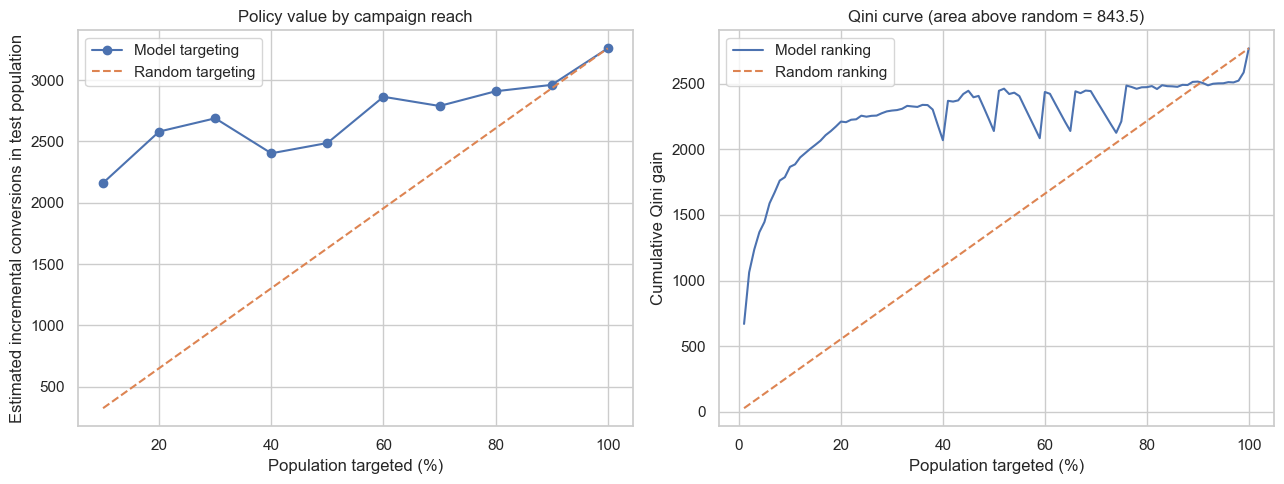

In [28]:
# Qini gain at cumulative fractions of the held-out ranking.
qini_fractions = np.linspace(0.01, 1.00, 100)
qini_gain = []
for fraction in qini_fractions:
    k = int(np.ceil(fraction * len(ranking)))
    selected = ranking[:k]
    y_selected = y_test[selected]
    z_selected = z_test[selected]
    n_t = z_selected.sum()
    n_c = k - n_t
    gain = (
        y_selected[z_selected == 1].sum()
        - y_selected[z_selected == 0].sum() * n_t / n_c
    )
    qini_gain.append(gain)

qini_gain = np.asarray(qini_gain)
qini_random = qini_fractions * qini_gain[-1]
qini_area_above_random = np.trapezoid(
    qini_gain - qini_random, x=qini_fractions
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    100 * policy_value.index,
    policy_value["incremental_conversions"],
    marker="o", label="Model targeting",
)
axes[0].plot(
    100 * policy_value.index,
    policy_value["random_targeting_benchmark"],
    linestyle="--", label="Random targeting",
)
axes[0].set(
    xlabel="Population targeted (%)",
    ylabel="Estimated incremental conversions in test population",
    title="Policy value by campaign reach",
)
axes[0].legend()

axes[1].plot(100 * qini_fractions, qini_gain, label="Model ranking")
axes[1].plot(100 * qini_fractions, qini_random, linestyle="--", label="Random ranking")
axes[1].set(
    xlabel="Population targeted (%)",
    ylabel="Cumulative Qini gain",
    title=f"Qini curve (area above random = {qini_area_above_random:,.1f})",
)
axes[1].legend()

plt.tight_layout()
plt.show()


In [29]:
top_decile = uplift_by_decile.loc[1]
bottom_decile = uplift_by_decile.loc[uplift_by_decile.index.max()]
top_20 = policy_value.loc[0.20]

print(f"Overall held-out ITT: {100 * overall_test_effect:.4f} percentage points")
print(f"Top-decile held-out uplift: {100 * top_decile.observed_test_uplift:.4f} percentage points")
print(f"Bottom-decile held-out uplift: {100 * bottom_decile.observed_test_uplift:.4f} percentage points")
print(f"Top-20% estimated incremental conversions: {top_20.incremental_conversions:,.1f}")
print(f"Top-20% random-targeting benchmark: {top_20.random_targeting_benchmark:,.1f}")
print(f"Qini area above random: {qini_area_above_random:,.1f}")


Overall held-out ITT: 0.1165 percentage points
Top-decile held-out uplift: 0.7727 percentage points
Bottom-decile held-out uplift: 0.1051 percentage points
Top-20% estimated incremental conversions: 2,580.1
Top-20% random-targeting benchmark: 651.7
Qini area above random: 843.5


### Business interpretation and decision rule

The model is commercially useful only if the held-out evidence—not the training fit—shows that high-ranked groups have greater incremental lift and that the policy curve beats random targeting over relevant budget levels.

If the ranking succeeds, the business idea is **incremental audience selection**: prioritize users whose conversion probability is most changed by campaign eligibility, rather than users who merely have the highest conversion probability.

With user-level advertising cost $c_i$ and profit per incremental conversion $m$, the ideal rule is

$$
\text{target user }i
\quad\text{when}\quad
m\widehat\tau(X_i)>c_i.
$$

Without cost and margin data, the policy table answers the narrower question: how many incremental conversions are associated with targeting the top 10%, 20%, and so on?

Important limitations:

- `f0`–`f11` are anonymized, so high-uplift encoded segments are not yet operational customer descriptions.
- Decile effects are group averages, not proof of any individual's causal response.
- Inspecting the test results repeatedly and then changing the model would turn the test set into a tuning set. Further model development requires a fresh validation/test split or cross-fitting.
- This is an ITT uplift model. Estimating the causal effect of actual ad exposure requires an instrumental-variables analysis and additional assumptions.


## 19. Suggested next stages

With the regression-adjusted ITT and an honest T-learner baseline in place, continue with:

1. Compare the T-learner with an S-learner or causal forest using validation data, not the held-out test outcomes.
2. Use cross-fitting to obtain out-of-fold uplift predictions for every observation and improve data efficiency.
3. Add campaign cost and conversion-margin assumptions to translate policy value into expected profit.
4. Estimate the effect of actual exposure using randomized assignment as an instrument, with explicit IV assumptions.
5. Check subgroup stability and repeat the analysis across time or campaign cohorts if those identifiers become available.

Keep the randomized overall ITT and honest held-out policy value as the benchmarks against which more complex models are judged.
